Criar uma rede neural com somente <b>uma saída</b>para prever somente <b>o valor do atributo global_sales</b>, que representa as vendas totais dos jogos. 

Recomendações abaixo:

- Os atributos que representam as vendas na América do Norte, Europa e Japão devem ser excluídos

- O número de neurônios na camada de entrada deverá ser modificado de acordo com a quantidade de atributos previsores

- A rede neural terá somente um neurônio na camada de saída

Utilizando a mesma estrutura da rede neural desenvolvida anteriormente, os resultados não serão tão bons quanto aos da execução anterior, portanto, podemos testar outras configurações conforme aprendemos durante todo o curso.

In [2]:
# no ambiente YouTube => anaconda

# Tarefa: Previsão do valor total de vendas regressão vídeo game

## Etapa 1: Importação das bibliotecas



In [3]:
import pandas as pd
import torch
from torch import nn, optim
import torch.nn.functional as F
import matplotlib.pyplot as plt
torch.__version__

'2.8.0+cu128'

## Etapa 2: Base de dados

In [4]:
torch.manual_seed(123)

In [5]:
# tratamento dos dados 

base = pd.read_csv('games.csv')

base = base.drop('Other_Sales', axis = 1)
base = base.drop('Developer', axis = 1)
base = base.drop('NA_Sales', axis = 1)
base = base.drop('EU_Sales', axis = 1)
base = base.drop('JP_Sales', axis = 1)
base = base.drop('Name', axis = 1)

base = base.dropna(axis = 0)

base = base.loc[base['Global_Sales'] > 1]

In [13]:
list(base.columns[[0, 1, 2, 3, 5, 6, 7, 8, 9]]) # previsores/feaatures

['Platform',
 'Year_of_Release',
 'Genre',
 'Publisher',
 'Critic_Score',
 'Critic_Count',
 'User_Score',
 'User_Count',
 'Rating']

In [15]:
list(base.columns[[4]]) # target

['Global_Sales']

In [22]:
print(list(base.columns[[0, 1, 2, 3, 5, 6, 7, 8, 9]]))
texto= f"""
One Hot Encoder

0 : {list(base.columns[[0, 1, 2, 3, 5, 6, 7, 8, 9]])[0]}
2 : {list(base.columns[[0, 1, 2, 3, 5, 6, 7, 8, 9]])[2]}
3 : {list(base.columns[[0, 1, 2, 3, 5, 6, 7, 8, 9]])[3]}
8 : {list(base.columns[[0, 1, 2, 3, 5, 6, 7, 8, 9]])[8]}

"""
print(texto)

['Platform', 'Year_of_Release', 'Genre', 'Publisher', 'Critic_Score', 'Critic_Count', 'User_Score', 'User_Count', 'Rating']

One Hot Encoder

0 : Platform
2 : Genre
3 : Publisher
8 : Rating




In [23]:
display(base.tail(2))

,Platform,Year_of_Release,Genre,Publisher,Global_Sales,Critic_Score,Critic_Count,User_Score,User_Count,Rating
2055,WiiU,2012.0,Action,Ubisoft,1.01,77.0,70.0,7.7,758.0,M
2056,WiiU,2016.0,Fighting,Namco Bandai Games,1.01,76.0,74.0,8,273.0,E10+


In [16]:
previsores = base.iloc[:, [0, 1, 2, 3, 5, 6, 7, 8, 9]].values
valor_vendas = base.iloc[:, 4].values


In [24]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
onehotencorder = ColumnTransformer(transformers=[("OneHot", OneHotEncoder(), [0, 2, 3, 8])], remainder='passthrough') 
previsores = onehotencorder.fit_transform(previsores).toarray()

previsores = torch.tensor(previsores, dtype = torch.float)
valor_vendas = torch.tensor(valor_vendas, dtype = torch.float).view(-1, 1)

dataset = torch.utils.data.TensorDataset(previsores, valor_vendas)
train_loader = torch.utils.data.DataLoader(dataset, batch_size = 100, shuffle = True) 

# misturar shuffle
# treinamento batch_size que vai de 100 em 100 dados


In [27]:
previsores

tensor([[  0.0000,   0.0000,   0.0000,  ...,  51.0000,   8.0000, 322.0000],
        [  0.0000,   0.0000,   0.0000,  ...,  73.0000,   8.3000, 709.0000],
        [  0.0000,   0.0000,   0.0000,  ...,  73.0000,   8.0000, 192.0000],
        ...,
        [  0.0000,   0.0000,   0.0000,  ...,  73.0000,   7.0000, 189.0000],
        [  0.0000,   0.0000,   0.0000,  ...,  70.0000,   7.7000, 758.0000],
        [  0.0000,   0.0000,   0.0000,  ...,  74.0000,   8.0000, 273.0000]])

## Etapa 3: Construção do modelo

In [28]:
previsores.shape

torch.Size([1307, 99])

In [30]:
print(f'Camada de entrada das features: {previsores.shape[1]}')

print(f'Camada de saída: {valor_vendas.shape[1]}')

neuronio_camada_oculta = (previsores.shape[1] + valor_vendas.shape[1])/2

print(f'Cálculo dos neurônios das camadas ocultas {neuronio_camada_oculta}')

Camada de entrada das features: 99
Camada de saída: 1
Cálculo dos neurônios das camadas ocultas 50.0


In [31]:
class regressor_torch(nn.Module):
    def __init__(self):
        super().__init__()
        self.dense0 = nn.Linear(99, 50)
        self.dense1 = nn.Linear(50, 50)
        self.activation = nn.Sigmoid() # sigmoid ideal para classificação binária
        self.output = nn.Linear(50, 1)
        # #nn.Linear(in_features, out_features) → camada totalmente conectada (densa), faz: 
        #→ transforma os 99 inputs em 50 neurônios. (dense0)

        
    def forward(self, X):
        # ligação das redes neurais -> fluxo da rede neural
        X = self.dense0(X)
        X = self.activation(X)
        X = self.dense1(X)
        X = self.activation(X)
        X = self.output(X)
        return X

In [32]:
regressor = regressor_torch()

In [33]:
regressor


regressor_torch(
  (dense0): Linear(in_features=99, out_features=50, bias=True)
  (dense1): Linear(in_features=50, out_features=50, bias=True)
  (activation): Sigmoid()
  (output): Linear(in_features=50, out_features=1, bias=True)
)

In [34]:
criterion = nn.MSELoss()
optimizer = optim.Adam(regressor.parameters())

## Etapa 4: Treinamento do modelo

In [35]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
device

'cpu'

In [36]:
regressor.to(device)

regressor_torch(
  (dense0): Linear(in_features=99, out_features=50, bias=True)
  (dense1): Linear(in_features=50, out_features=50, bias=True)
  (activation): Sigmoid()
  (output): Linear(in_features=50, out_features=1, bias=True)
)

In [37]:
for epoch in range(5000):
    
    running_loss = 0.
    running_mse = 0.
    
    for i, data in enumerate(train_loader):
        inputs, labels = data
        inputs, labels = inputs.to(device), labels.to(device)
       
        optimizer.zero_grad()

        outputs = regressor(inputs)

        mse = F.mse_loss(outputs, labels).item()
        
        running_mse += mse

        loss = criterion(outputs, labels)
        loss.backward()
        
        optimizer.step()

        loss = loss.item()
        running_loss += loss

        print('\rÉPOCA {:3d} - Loop {:3d} de {:3d}: perda {:06.2f} - MSE {:06.2f}'.format(epoch+1, i+1, len(previsores)//100, loss, mse), end = '\r')

    print('Época %3d finalizada: perda %.5f - MSE %.5f     ' % (epoch+1, running_loss/len(train_loader), running_mse/len(train_loader)))

Época   1 finalizada: perda 20.45546 - MSE 20.45546     
Época   2 finalizada: perda 17.27177 - MSE 17.27177     
Época   3 finalizada: perda 15.27751 - MSE 15.27751     
Época   4 finalizada: perda 15.25613 - MSE 15.25613     
Época   5 finalizada: perda 13.96079 - MSE 13.96079     
Época   6 finalizada: perda 13.64148 - MSE 13.64148     
Época   7 finalizada: perda 13.68728 - MSE 13.68728     
Época   8 finalizada: perda 14.01771 - MSE 14.01771     
Época   9 finalizada: perda 19.54440 - MSE 19.54440     
Época  10 finalizada: perda 14.45554 - MSE 14.45554     
Época  11 finalizada: perda 13.46952 - MSE 13.46952     
Época  12 finalizada: perda 13.46024 - MSE 13.46024     
Época  13 finalizada: perda 13.91721 - MSE 13.91721     
Época  14 finalizada: perda 13.32316 - MSE 13.32316     
Época  15 finalizada: perda 13.40354 - MSE 13.40354     
Época  16 finalizada: perda 13.39637 - MSE 13.39637     
Época  17 finalizada: perda 13.32948 - MSE 13.32948     
Época  18 finalizada: perda 13.

## Etapa 5: Avaliação do modelo

In [38]:
regressor.eval()
previsores = previsores.to(device)
previsoes = regressor(previsores)

In [39]:
previsoes

tensor([[3.9198],
        [3.9198],
        [3.4403],
        ...,
        [2.0616],
        [3.9198],
        [3.9188]], grad_fn=<AddmmBackward0>)

In [40]:
previsoes = previsoes.to(torch.device('cpu')).detach().numpy()

In [41]:
previsoes.mean(axis = 0) #média da coluna inteira

array([2.7599711], dtype=float32)

In [42]:
valor_vendas.mean(axis = 0)

tensor([2.8374])

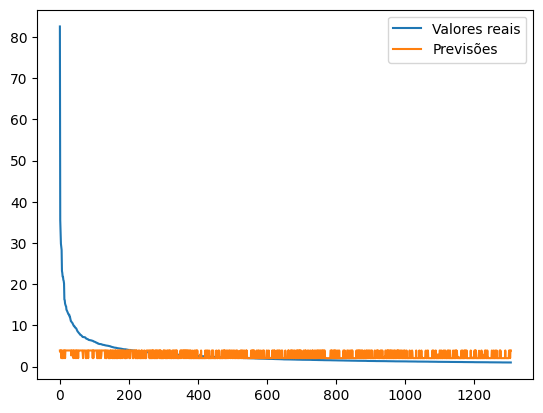

In [43]:
plt.plot(valor_vendas)
plt.plot(previsoes)
plt.legend(['Valores reais', 'Previsões']);